# Steam's game titles' user review analysis and topic modelling

# 1. General task description

Steam is currently the biggest digital game marketplace, operated by Valve Corporation. As with any other marketplace, all of the games Steam puts up for sale (there are also free-to-play titles) get reviews from the platform's users. In addition, the review function includes a thumbs up/down button, which implies that a user, based on the review, either recommends the game (positive reaction), or not (negative reaction). The aim of this natural language processing task is to predict whether a user will recommend a title, based on the review.

More concretely, this task is divided into two parts:

1. Text classification - predicting whether a user will recommend a title or not based on the review

2. Topic modeling - aiming to cluster the main topics in order to find correlations between them, also checking for the most popular topics

# 2. Composition of the notebook
This notebook is composed is several parts:

a. General dataset description

b. Pipeline description

c. Data preprocessing

d. Review classification

e. Hyperparameter tuning

f. Topic modelling

g. Conclusion

# a. General dataset description

The dataset used for this task was acquired from Kaggle: https://www.kaggle.com/datasets/arashnic/game-review-dataset, more specifically the train_csv dataset. The dataset has five columns:

1. review_id : ID of a certain review, represented by a unique number

2. title : Name of the game

3. year : Year in which the review was posted

4. user_review : Review posted by the user

5. user_suggestion : Designated either 0 or 1; 0 meaning that the user will not recommend this game, and 1 meaning that the user will recommend the game

The only relevant columns to the task are user_review and user_suggestion, because the name of the game, year and id do not play a role in the user suggesting a game.

# b. Pipeline description
This pipeline is divided in three main parts:

1. Data exploration, preprocessing and cleaning - here the dataset will be explored, cleaned of empty values and duplicates, also preprocessed in a suitable format using nltk, so as to be prepared for modelling. The final step will be to split the data.

2. Review classification, hyperparameter tuning and evaluation - here a pipeline of MultinomialNB and CountVectorizer will be used to create the model; then the model's hyperparameters will be tuned using GridSearchCV, and finally the predictions will be evaluated using a classification report.

3. Topic modelling - BERTopic, a deep learning model, will be used to here for the task at hand. The data will be transformed, the topics and their probablities will be extracted. Finally a cluster diagram will be displayed, illustrating the correlations between topics, also showing which topics are the most popular.

# c. Data preprocessing

BERTopic needs to be manually installed, since it is not included in Scikit-Learn (the output is hidden for space purposes).

In [ ]:
pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.7 MB/s eta 0:00:00


Here all the libraries necessary for the task have been imported.

In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from transformers import pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from bertopic import BERTopic
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer

Here some dependencies of NLTK are being installed. Punkt is a module that is generally needed for tokenization. Wordnet relates to stemming and lemmatization. Punkt tab is necessary for preprocessing tabular data, like a Pandas DataFrame column for example.

In [ ]:
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

The dataset is being imported.

In [ ]:
review_df = pd.read_csv("/content/train.csv")

Here are shown the top five rows of the dataset.

In [ ]:
review_df.head()

,review_id,title,year,user_review,user_suggestion
0,1,Spooky's Jump Scare Mansion,2016.0,I'm scared and hearing creepy voices. So I'll...,1
1,2,Spooky's Jump Scare Mansion,2016.0,"Best game, more better than Sam Pepper's YouTu...",1
2,3,Spooky's Jump Scare Mansion,2016.0,"A littly iffy on the controls, but once you kn...",1
3,4,Spooky's Jump Scare Mansion,2015.0,"Great game, fun and colorful and all that.A si...",1
4,5,Spooky's Jump Scare Mansion,2015.0,Not many games have the cute tag right next to...,1


Some general information about the columns.

In [ ]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17494 entries, 0 to 17493
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   review_id        17494 non-null  int64  
 1   title            17494 non-null  object 
 2   year             17316 non-null  float64
 3   user_review      17494 non-null  object 
 4   user_suggestion  17494 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 683.5+ KB


Checking for missing values.

In [ ]:
review_df.isna().sum()

,0
review_id,0
title,0
year,178
user_review,0
user_suggestion,0


Dropping the rows with missing values.

In [ ]:
review_df = review_df.dropna(axis = 0)

Checking for duplicates among values.

In [ ]:
review_df.duplicated().sum()

0

This is a function that preprocesses text. Steps are these:

1. The text is converted to lowercase, so that it is consistent and less complex

2. The text is tokenized word for word for easy readability and processing

3. Stop words are removed

4. The text is lemmatized (in other words returned to base form), so it can be more easily grouped

5. The text strings are joined, making them ready for vectorization

In [ ]:
def preprocess(text):
  text = text.lower()
  tokens = word_tokenize(text)
  tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS]
  lemmatizer = WordNetLemmatizer()
  tokens = [lemmatizer.lemmatize(t) for t in tokens]
  return " ".join(tokens)

Here the function is applied to the user_review column, since it's the one we need. The reason why is that in this way each review is uniformly preprocessed. Afterwards the top five rows are displayed.

In [ ]:
review_df.user_review = review_df.user_review.apply(preprocess)
print(review_df.head())

   review_id                        title    year  \
0          1  Spooky's Jump Scare Mansion  2016.0   
1          2  Spooky's Jump Scare Mansion  2016.0   
2          3  Spooky's Jump Scare Mansion  2016.0   
3          4  Spooky's Jump Scare Mansion  2015.0   
4          5  Spooky's Jump Scare Mansion  2015.0   

                                         user_review  user_suggestion  
0  'm scared hearing creepy voice . 'll pause mom...                1  
1  best game , better sam pepper 's youtube accou...                1  
2  littly iffy control , know play , easy master ...                1  
3  great game , fun colorful that.a note , : gett...                1  
4  game cute tag right horror tag steam.i played ...                1  


A display of the preprocessed user_review column.

In [ ]:
review_df.user_review

,user_review
0,'m scared hearing creepy voice . 'll pause mom...
1,"best game , better sam pepper 's youtube accou..."
2,"littly iffy control , know play , easy master ..."
3,"great game , fun colorful that.a note , : gett..."
4,game cute tag right horror tag steam.i played ...
...,...
17487,played extensively year tried mmo 's . unfortu...
17488,"mmorpg 've played having played , year playing..."
17489,"arguably single greatest mmorp exists today , ..."
17490,"older game , sure , charm hold special place h..."


A bar graph of the 15 most popular games reviewed.

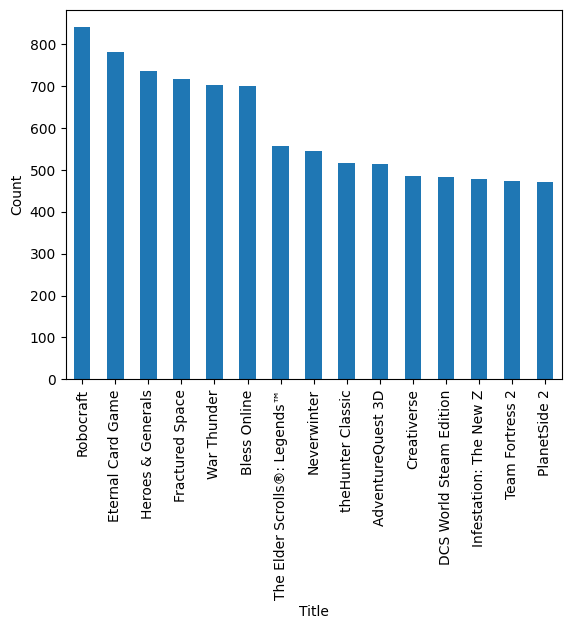

In [ ]:
review_df.title.value_counts().iloc[0:15].plot(kind = "bar", xlabel = "Title", ylabel = "Count");

First step of data splitting:

1. X is the feature needed for predictions, user_review

2. y is the target column, user_suggestion

In [ ]:
X = review_df.user_review
y = review_df.user_suggestion

Second step: using the train_test_split module to split the data in the train and test sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# d. Review classification

The model used will be a pipeline combining both CountVectorizer and MultinomialNB. The reasoning is to save both time and space, so as not to include needless lines of code. Here the pipeline will be initalized and assigned to "model".

In [ ]:
model = Pipeline(steps = [("vec", CountVectorizer(stop_words = "english")), ('mb', MultinomialNB())])

# e. Hyperparameter tuning

Before fitting any data to the model, in order to avoid redundancies:

1. a parameter grid for both will be created, showing a range of values to test

2. the model will be tuned by initializing GridSearchCV with the necessary variables

In [ ]:
param_grid = {'vec__max_df': [0.75, 1.0],
              'vec__ngram_range': [(1, 1), (1, 2)],
              'mb__alpha': [0.1, 1.0]}

mb_grid = GridSearchCV(model,
                       param_grid,
                       cv=5,
                       n_jobs=-1,
                       verbose=1)

mb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vec',
                                        CountVectorizer(stop_words='english')),
                                       ('mb', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'mb__alpha': [0.1, 1.0], 'vec__max_df': [0.75, 1.0],
                         'vec__ngram_range': [(1, 1), (1, 2)]},
             verbose=1)

The model with the best parameters will be automatically loaded, so that predictions could be made.

In [ ]:
best_model = mb_grid.best_estimator_

Here we make predictions with the best model using the test data.

In [ ]:
y_pred = best_model.predict(X_test)

This is a classification report table displaying all the common metrics, alongside the macro and weighted average scores.

In [ ]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.87      0.73      0.79      1483
           1       0.82      0.92      0.87      1981

    accuracy                           0.84      3464
   macro avg       0.84      0.82      0.83      3464
weighted avg       0.84      0.84      0.84      3464



From the report, a few things can be deduced:

1. The model predicted more positive than negative values correctly, suggesting a class imbalance

2. The macro average score remained over 80%, implying that the model is doing a good job (more strongly evidenced by the fact that the weighted average score across all models is 84%)

3. The metric we need, f1-score, has done well, showing the effectiveness of the model

4. It can also be said that the model is better at predicting positive values

# f. Topic modelling

We create an instance of a BERTopic model, more specifically all-MiniLM-L6-v2, that deals with the English language and it is very efficient. The reason why LatentDirichletAllocation is not deployed is due to time required.

In [ ]:
topic_model = BERTopic(embedding_model="all-MiniLM-L6-v2")

In order to extract the topics and probabilities from the user_review column (X), we fit the data to the model, then transform it.

In [ ]:
topics, probablities = topic_model.fit_transform(X)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Here we get some general information on the topics extracted. There are in total 104 topics. The count shows the number of documents of that topic, name is the name of the topic, representation shows the key words, representative docs shows the key documents.

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,6470,-1_game_just_play_time,"[game, just, play, time, like, good, early, ac...",[review 'm mainly going focus free2play/pay2wi...
1,0,1384,0_card_deck_hearthstone_magic,"[card, deck, hearthstone, magic, mtg, mana, et...","[early access reviewit doe thing right , like ..."
2,1,455,1_ship_space_fractured_moba,"[ship, space, fractured, moba, early, capital,...",[early access reviewlove game ! -diverse ship ...
3,2,440,2_flight_aircraft_dc_plane,"[flight, aircraft, dc, plane, sim, simulator, ...","[hardcore flight combat simulation , dc ca n't..."
4,3,399,3_animal_hunt_hunting_deer,"[animal, hunt, hunting, deer, license, members...",[thehunter - review designed eliminate stress ...
...,...,...,...,...,...
99,98,12,98_german_map_rts_germany,"[german, map, rts, germany, reto, terrible, gu...",[game make quit delete game play . blance game...
100,99,11,99_old_family_kid_child,"[old, family, kid, child, grandson, year, weea...",[game best played . started playing nostalgia ...
101,100,11,100_bullet_recoil_gun_ironic,"[bullet, recoil, gun, ironic, access, early, i...",[early access review+pros nice looking mapsa w...
102,101,10,101_plane_tier_research_rp,"[plane, tier, research, rp, bomber, ge, thunde...",[( sorry bad english ) gamer played played wor...


This is an intertopic distance map that shows all the topics in clusters (circles; the bigger the circle. the bigger its count). The slider in the bottom highlights the specific topic in red.

In [ ]:
topic_model.visualize_topics()

In this diagram there are a few important topic clusters. Let's address each one:
1. Cluster including topic 0: casual pvp games (evidenced by words like quest, moba, brawlhalla)

2. Cluster including topic 3: game updates and the respective user experiences (product, early access, pay2win)

3. Cluster including topic 7: vehicle-related games (car, flight, plane, aircraft)

4. Cluster including topic 8: massively multiplayer online role-playing games (mmo, mmorpg, everquest)

5. Cluster including topic 14: negative user experiences (crash, bug, lag, malware)

What can be drawn from this is that customers tend to review more on casual pvp and mmorpgs (massively multiplayer online role-playing games), game updates, in-game experiences, including their negative experiences, which all play a good role in the user recommending a game or not.

# g. Conclusion

To conclude, this two-fold analysis showed how whether a user would recommend a game or not, based on the review. The tuned model held an average score of 84%, even though it was slightly biased towards predicting positive values. On the other hand, the topic modelling analysis helped make better context on the reviews, while reducing dimensionality.

This analysis was important in a business sense because reviews generally reflect the user experience. Steam, by analyzing the reviews, can make several decisions:

1. Promoting a game genre

2. Making heavy discounts for poorly reviewed games

3. Improving the user experience

4. Removing the games with negative reviews from the marketplace altogether

Regarding the pipeline, the main strength is putting up a good performance in a relatively large dataset. The main weakness is taking up a lot of time to fit data, especially with more complex models like LDA. This was by far the least time-consuming and most efficient approach.